Below is a practical starter solution for your earlier buy-and-build cross-sell + margin leak use case, implemented as a Google ADK agent scaffold in Python. I’m tailoring it to the Certek-style scenario we discussed, because that gives you a concrete demo rather than a generic framework sketch. Your own internal notes already mention selecting Google ADK and keeping internal references to an ADK template, which makes this a good fit for how you’ve been positioning agentic solutions on GCP.

The public ADK docs describe Agent Development Kit (ADK) as an open-source framework for building, debugging and deploying AI agents, with support for agents, workflows, tools and local development via CLI or web UI. The official Python quickstart shows pip install google-adk, adk create ..., a root_agent entry point, plain Python tool functions, and local execution with adk run or adk web. The current package page also says ADK 2.2.0 is published on PyPI and that the package currently requires Python 3.11+, while the older quickstart snippet says Python 3.10+. To avoid version friction, I’d use Python 3.11+.

Your recent internal materials also emphasise human-in-the-loop, tool-driven agents, and decomposing workflows into smaller specialist steps rather than relying on a giant monolithic prompt. That lines up well with this design: one ADK root agent, a set of deterministic Python tools, and an approval gate before any commercial recommendation is acted on.

This ADK solution will:

1. Resolve a customer across acquired subsidiaries
2. Find cross-sell opportunities across the group
3. Detect margin leaks in jobs / contracts
4. Prioritise recommended actions
5. Require human approval for medium-confidence or pricing-sensitive actions

For your Certek-style use case, the synthetic subsidiaries are:
- AlphaBiolabs for workplace / health / toxicology-style testing.
- JSS Medical Research for CRO / clinical / post-approval support.
- ARC Pharma for QC batch release and analytical testing.

In [1]:
# buy_build_ai/
# ├── __init__.py
# ├── agent.py
# ├── tools.py
# ├── scoring.py
# ├── data/
# │   ├── subsidiaries.csv
# │   ├── customers.csv
# │   ├── customer_service_history.csv
# │   ├── service_catalog.csv
# │   ├── adjacency_rules.csv
# │   └── jobs.csv
# └── .env

In [ ]:
model_name="gemini-3.1-flash-lite"
api_key="<give-here>"
import os
import pandas as pd
from datetime import datetime, timedelta
from typing import Optional
from google import genai

In [3]:
def call_gemini_direct(prompt: str) -> str:
    """
    Calls Gemini directly with an API key passed in code.
    This bypasses ADK's native Gemini auth path.
    """
    client = genai.Client(api_key=api_key)

    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
    )

    return response.text

In [4]:

from functools import cached_property
from google.genai import Client, types
from google.adk.models.google_llm import Gemini

class GeminiWithApiKey(Gemini):
    api_key: str

    @cached_property
    def api_client(self) -> Client:
        return Client(
            api_key=self.api_key,
            http_options=types.HttpOptions(headers=self._tracking_headers()),
        )

In [5]:
import pandas as pd

# ------------------------------
# Subsidiaries
# ------------------------------
subsidiaries = pd.DataFrame([
    {"subsidiary_id": "S1", "subsidiary_name": "AlphaBiolabs", "target_margin_pct": 46, "current_capacity_pct": 72},
    {"subsidiary_id": "S2", "subsidiary_name": "JSS Medical Research", "target_margin_pct": 34, "current_capacity_pct": 68},
    {"subsidiary_id": "S3", "subsidiary_name": "ARC Pharma", "target_margin_pct": 41, "current_capacity_pct": 63},
])

# ------------------------------
# Service Catalogue
# ------------------------------
services = pd.DataFrame([
    {"service_id": "SV1", "service_name": "Workplace Drug Testing", "provider_subsidiary_id": "S1", "avg_deal_size_gbp": 28000, "target_margin_pct": 48},
    {"service_id": "SV2", "service_name": "Occupational Health Screening", "provider_subsidiary_id": "S1", "avg_deal_size_gbp": 18000, "target_margin_pct": 44},
    {"service_id": "SV4", "service_name": "Phase II/III Clinical Operations", "provider_subsidiary_id": "S2", "avg_deal_size_gbp": 250000, "target_margin_pct": 33},
    {"service_id": "SV5", "service_name": "Post-Approval Studies", "provider_subsidiary_id": "S2", "avg_deal_size_gbp": 175000, "target_margin_pct": 36},
    {"service_id": "SV6", "service_name": "Medical Writing & Data Management", "provider_subsidiary_id": "S2", "avg_deal_size_gbp": 95000, "target_margin_pct": 38},
    {"service_id": "SV7", "service_name": "QC Batch Release Testing", "provider_subsidiary_id": "S3", "avg_deal_size_gbp": 140000, "target_margin_pct": 42},
    {"service_id": "SV8", "service_name": "Method Validation", "provider_subsidiary_id": "S3", "avg_deal_size_gbp": 85000, "target_margin_pct": 45},
])

# ------------------------------
# Customers
# ------------------------------
customers = pd.DataFrame([
    {"customer_id": "C101", "customer_name": "MedNova Pharma", "sector": "Pharma", "region": "UK", "current_group_spend_gbp": 420000},
    {"customer_id": "C102", "customer_name": "BioSterile Therapeutics", "sector": "Biotech", "region": "EU", "current_group_spend_gbp": 260000},
    {"customer_id": "C103", "customer_name": "NutriHealth Labs", "sector": "Nutraceutical", "region": "North America", "current_group_spend_gbp": 180000},
    {"customer_id": "C104", "customer_name": "CareGene Diagnostics", "sector": "Diagnostics", "region": "UK", "current_group_spend_gbp": 140000},
    {"customer_id": "C105", "customer_name": "NorthBridge Manufacturing", "sector": "Industrial Employer", "region": "UK", "current_group_spend_gbp": 95000},
    {"customer_id": "C106", "customer_name": "Regenera Life Sciences", "sector": "Pharma", "region": "Global", "current_group_spend_gbp": 510000},
])

# ------------------------------
# Customer Service History
# ------------------------------
history = pd.DataFrame([
    {"customer_id": "C101", "service_id": "SV4", "provider_subsidiary_id": "S2", "total_spend_12m_gbp": 420000, "purchase_count_12m": 2},
    {"customer_id": "C102", "service_id": "SV7", "provider_subsidiary_id": "S3", "total_spend_12m_gbp": 260000, "purchase_count_12m": 4},
    {"customer_id": "C103", "service_id": "SV5", "provider_subsidiary_id": "S2", "total_spend_12m_gbp": 180000, "purchase_count_12m": 1},
    {"customer_id": "C104", "service_id": "SV2", "provider_subsidiary_id": "S1", "total_spend_12m_gbp": 140000, "purchase_count_12m": 5},
    {"customer_id": "C105", "service_id": "SV1", "provider_subsidiary_id": "S1", "total_spend_12m_gbp": 95000, "purchase_count_12m": 6},
    {"customer_id": "C106", "service_id": "SV7", "provider_subsidiary_id": "S3", "total_spend_12m_gbp": 310000, "purchase_count_12m": 3},
    {"customer_id": "C106", "service_id": "SV6", "provider_subsidiary_id": "S2", "total_spend_12m_gbp": 200000, "purchase_count_12m": 2},
])

# ------------------------------
# Cross-sell Adjacency Rules
# ------------------------------
adjacency = pd.DataFrame([
    {"anchor_service_id": "SV4", "recommended_service_id": "SV7", "base_confidence": 0.84, "reason": "Phase II/III clients often need QC batch release"},
    {"anchor_service_id": "SV5", "recommended_service_id": "SV7", "base_confidence": 0.76, "reason": "Post-approval studies pair naturally with batch release"},
    {"anchor_service_id": "SV7", "recommended_service_id": "SV5", "base_confidence": 0.78, "reason": "Batch release clients often need post-approval support"},
    {"anchor_service_id": "SV7", "recommended_service_id": "SV6", "base_confidence": 0.69, "reason": "Batch release clients frequently need medical writing"},
    {"anchor_service_id": "SV1", "recommended_service_id": "SV2", "base_confidence": 0.66, "reason": "Drug testing employers often add occupational health screening"},
])

# ------------------------------
# Jobs (for margin analysis)
# ------------------------------
jobs = pd.DataFrame([
    # C105 NorthBridge | S1 AlphaBiolabs | spend cap £95k
    {"job_id": "J1001", "customer_id": "C105", "subsidiary_id": "S1", "service_id": "SV1", "quoted_value_gbp": 18500, "invoiced_value_gbp": 17800, "direct_labour_gbp": 6200, "travel_logistics_gbp": 1700, "subcontract_gbp": 0, "rework_gbp": 1800, "other_direct_cost_gbp": 1200, "rush_flag": "Y"},
    {"job_id": "J1002", "customer_id": "C105", "subsidiary_id": "S1", "service_id": "SV2", "quoted_value_gbp": 19000, "invoiced_value_gbp": 18500, "direct_labour_gbp": 7200, "travel_logistics_gbp": 900, "subcontract_gbp": 0, "rework_gbp": 400, "other_direct_cost_gbp": 800, "rush_flag": "N"},
    # C101 MedNova Pharma | S2 JSS Medical Research | spend cap £420k
    {"job_id": "J1003", "customer_id": "C101", "subsidiary_id": "S2", "service_id": "SV4", "quoted_value_gbp": 96000, "invoiced_value_gbp": 96000, "direct_labour_gbp": 51200, "travel_logistics_gbp": 6800, "subcontract_gbp": 4200, "rework_gbp": 3200, "other_direct_cost_gbp": 9000, "rush_flag": "N"},
    {"job_id": "J1004", "customer_id": "C101", "subsidiary_id": "S2", "service_id": "SV5", "quoted_value_gbp": 85000, "invoiced_value_gbp": 82000, "direct_labour_gbp": 38000, "travel_logistics_gbp": 5200, "subcontract_gbp": 2000, "rework_gbp": 4500, "other_direct_cost_gbp": 7000, "rush_flag": "N"},
    {"job_id": "J1006", "customer_id": "C101", "subsidiary_id": "S2", "service_id": "SV6", "quoted_value_gbp": 48000, "invoiced_value_gbp": 48000, "direct_labour_gbp": 19500, "travel_logistics_gbp": 1200, "subcontract_gbp": 0, "rework_gbp": 800, "other_direct_cost_gbp": 3500, "rush_flag": "N"},
    # C102 BioSterile Therapeutics | S3 ARC Pharma | spend cap £260k
    {"job_id": "J1005", "customer_id": "C102", "subsidiary_id": "S3", "service_id": "SV7", "quoted_value_gbp": 42000, "invoiced_value_gbp": 42000, "direct_labour_gbp": 15900, "travel_logistics_gbp": 900, "subcontract_gbp": 0, "rework_gbp": 5400, "other_direct_cost_gbp": 11400, "rush_flag": "Y"},
    {"job_id": "J1007", "customer_id": "C102", "subsidiary_id": "S3", "service_id": "SV8", "quoted_value_gbp": 55000, "invoiced_value_gbp": 54000, "direct_labour_gbp": 19000, "travel_logistics_gbp": 1100, "subcontract_gbp": 0, "rework_gbp": 2200, "other_direct_cost_gbp": 5800, "rush_flag": "N"},
    # C103 NutriHealth Labs | S2 JSS Medical Research | spend cap £180k
    {"job_id": "J1008", "customer_id": "C103", "subsidiary_id": "S2", "service_id": "SV5", "quoted_value_gbp": 90000, "invoiced_value_gbp": 88000, "direct_labour_gbp": 39000, "travel_logistics_gbp": 3200, "subcontract_gbp": 1500, "rework_gbp": 1200, "other_direct_cost_gbp": 6500, "rush_flag": "N"},
    {"job_id": "J1009", "customer_id": "C103", "subsidiary_id": "S2", "service_id": "SV6", "quoted_value_gbp": 45000, "invoiced_value_gbp": 43000, "direct_labour_gbp": 17500, "travel_logistics_gbp": 1400, "subcontract_gbp": 0, "rework_gbp": 3100, "other_direct_cost_gbp": 4200, "rush_flag": "Y"},
    # C104 CareGene Diagnostics | S1 AlphaBiolabs | spend cap £140k
    {"job_id": "J1010", "customer_id": "C104", "subsidiary_id": "S1", "service_id": "SV2", "quoted_value_gbp": 38000, "invoiced_value_gbp": 38000, "direct_labour_gbp": 15200, "travel_logistics_gbp": 800, "subcontract_gbp": 0, "rework_gbp": 500, "other_direct_cost_gbp": 2800, "rush_flag": "N"},
    {"job_id": "J1011", "customer_id": "C104", "subsidiary_id": "S1", "service_id": "SV1", "quoted_value_gbp": 29000, "invoiced_value_gbp": 27500, "direct_labour_gbp": 10800, "travel_logistics_gbp": 1600, "subcontract_gbp": 0, "rework_gbp": 2900, "other_direct_cost_gbp": 2200, "rush_flag": "Y"},
    # C106 Regenera Life Sciences | S2 JSS Medical Research + S3 ARC Pharma | spend cap £510k
    {"job_id": "J1012", "customer_id": "C106", "subsidiary_id": "S3", "service_id": "SV7", "quoted_value_gbp": 145000, "invoiced_value_gbp": 145000, "direct_labour_gbp": 54000, "travel_logistics_gbp": 3800, "subcontract_gbp": 2500, "rework_gbp": 1800, "other_direct_cost_gbp": 11200, "rush_flag": "N"},
    {"job_id": "J1013", "customer_id": "C106", "subsidiary_id": "S3", "service_id": "SV8", "quoted_value_gbp": 88000, "invoiced_value_gbp": 86000, "direct_labour_gbp": 31000, "travel_logistics_gbp": 2100, "subcontract_gbp": 0, "rework_gbp": 4200, "other_direct_cost_gbp": 7500, "rush_flag": "N"},
    {"job_id": "J1014", "customer_id": "C106", "subsidiary_id": "S2", "service_id": "SV6", "quoted_value_gbp": 97000, "invoiced_value_gbp": 95000, "direct_labour_gbp": 38500, "travel_logistics_gbp": 2600, "subcontract_gbp": 1000, "rework_gbp": 1500, "other_direct_cost_gbp": 8200, "rush_flag": "N"},
])

### Synthetic Data Overview

Six DataFrames form the in-memory data layer for this demo. Each maps to a CSV file that would be loaded from `data/` in a production deployment.

---

**`subsidiaries`** — the three acquired group entities (3 rows × 4 cols)
- `subsidiary_id`: unique identifier — S1, S2, S3
- `subsidiary_name`: AlphaBiolabs (workplace/health testing), JSS Medical Research (CRO/clinical), ARC Pharma (QC/analytical)
- `target_margin_pct`: group-level gross margin target for that entity — 46%, 34%, 41%
- `current_capacity_pct`: current utilisation as % of total delivery capacity — used to downweight cross-sell recommendations to over-stretched subsidiaries

---

**`services`** — the service catalogue across all three subsidiaries (7 rows × 5 cols)
- `service_id`: unique identifier — SV1, SV2, SV4–SV8 (no SV3 in this dataset)
- `service_name`: e.g. Workplace Drug Testing, Phase II/III Clinical Operations, QC Batch Release Testing
- `provider_subsidiary_id`: which subsidiary delivers the service (S1, S2 or S3)
- `avg_deal_size_gbp`: average annual contract value — ranges from £18k (Occupational Health) to £250k (Phase II/III)
- `target_margin_pct`: expected gross margin for that service line — used as the benchmark in margin leak detection

---

**`customers`** — known group customer accounts (6 rows × 5 cols)
- `customer_id`: unique identifier — C101 to C106
- `customer_name`: e.g. MedNova Pharma, BioSterile Therapeutics, NorthBridge Manufacturing
- `sector`: industry vertical — Pharma, Biotech, Nutraceutical, Diagnostics, Industrial Employer
- `region`: geographic region — UK, EU, North America, Global
- `current_group_spend_gbp`: total spend across all subsidiaries in the last 12 months — ranges from £95k (NorthBridge) to £510k (Regenera)

---

**`history`** — customer service purchase history over the last 12 months (7 rows × 5 cols)
- `customer_id`: links to `customers`
- `service_id`: which service was purchased — links to `services`
- `provider_subsidiary_id`: which subsidiary fulfilled the engagement
- `total_spend_12m_gbp`: total spend on that service in the period
- `purchase_count_12m`: number of discrete purchases — C105 (NorthBridge) has the highest frequency at 6, indicating a recurring operational relationship

---

**`adjacency`** — cross-sell rules derived from co-purchase patterns (5 rows × 4 cols)
- `anchor_service_id`: the service the customer currently buys
- `recommended_service_id`: the service to recommend next
- `base_confidence`: probability (0–1) that a customer buying the anchor will convert on the recommendation — highest pairing is SV4→SV7 at 0.84
- `reason`: plain-English explanation of the commercial logic behind each pairing

---

**`jobs`** — individual job-level delivery and cost records (3 rows × 12 cols)
- `job_id`: unique job reference — J1001, J1003, J1005
- `customer_id` / `subsidiary_id` / `service_id`: foreign keys linking to their respective tables
- `quoted_value_gbp`: the value agreed at point of sale
- `invoiced_value_gbp`: the value actually billed — any gap from quoted indicates quote-to-invoice erosion
- `direct_labour_gbp`, `travel_logistics_gbp`, `subcontract_gbp`, `rework_gbp`, `other_direct_cost_gbp`: itemised direct cost buckets used to compute actual gross margin
- `rush_flag`: Y/N — J1001 and J1005 are rush jobs, a key contributor to margin compression in both cases

In [6]:
print(f'subsidiaries: {subsidiaries.shape}')
print(f'services: {services.shape}')
print(f'customers: {customers.shape}')
print(f'history: {history.shape}')
print(f'adjacency: {adjacency.shape}')
print(f'jobs: {jobs.shape}')
# print(jobs.describe())

subsidiaries: (3, 4)
services: (7, 5)
customers: (6, 5)
history: (7, 5)
adjacency: (5, 4)
jobs: (14, 12)


In [7]:
customers

,customer_id,customer_name,sector,region,current_group_spend_gbp
0,C101,MedNova Pharma,Pharma,UK,420000
1,C102,BioSterile Therapeutics,Biotech,EU,260000
2,C103,NutriHealth Labs,Nutraceutical,North America,180000
3,C104,CareGene Diagnostics,Diagnostics,UK,140000
4,C105,NorthBridge Manufacturing,Industrial Employer,UK,95000
5,C106,Regenera Life Sciences,Pharma,Global,510000


In [8]:
subsidiaries

,subsidiary_id,subsidiary_name,target_margin_pct,current_capacity_pct
0,S1,AlphaBiolabs,46,72
1,S2,JSS Medical Research,34,68
2,S3,ARC Pharma,41,63


In [9]:
services

,service_id,service_name,provider_subsidiary_id,avg_deal_size_gbp,target_margin_pct
0,SV1,Workplace Drug Testing,S1,28000,48
1,SV2,Occupational Health Screening,S1,18000,44
2,SV4,Phase II/III Clinical Operations,S2,250000,33
3,SV5,Post-Approval Studies,S2,175000,36
4,SV6,Medical Writing & Data Management,S2,95000,38
5,SV7,QC Batch Release Testing,S3,140000,42
6,SV8,Method Validation,S3,85000,45


In [10]:
history

,customer_id,service_id,provider_subsidiary_id,total_spend_12m_gbp,purchase_count_12m
0,C101,SV4,S2,420000,2
1,C102,SV7,S3,260000,4
2,C103,SV5,S2,180000,1
3,C104,SV2,S1,140000,5
4,C105,SV1,S1,95000,6
5,C106,SV7,S3,310000,3
6,C106,SV6,S2,200000,2


In [11]:
adjacency

,anchor_service_id,recommended_service_id,base_confidence,reason
0,SV4,SV7,0.84,Phase II/III clients often need QC batch release
1,SV5,SV7,0.76,Post-approval studies pair naturally with batc...
2,SV7,SV5,0.78,Batch release clients often need post-approval...
3,SV7,SV6,0.69,Batch release clients frequently need medical ...
4,SV1,SV2,0.66,Drug testing employers often add occupational ...


In [12]:
jobs

,job_id,customer_id,subsidiary_id,service_id,quoted_value_gbp,invoiced_value_gbp,direct_labour_gbp,travel_logistics_gbp,subcontract_gbp,rework_gbp,other_direct_cost_gbp,rush_flag
0,J1001,C105,S1,SV1,18500,17800,6200,1700,0,1800,1200,Y
1,J1002,C105,S1,SV2,19000,18500,7200,900,0,400,800,N
2,J1003,C101,S2,SV4,96000,96000,51200,6800,4200,3200,9000,N
3,J1004,C101,S2,SV5,85000,82000,38000,5200,2000,4500,7000,N
4,J1006,C101,S2,SV6,48000,48000,19500,1200,0,800,3500,N
5,J1005,C102,S3,SV7,42000,42000,15900,900,0,5400,11400,Y
6,J1007,C102,S3,SV8,55000,54000,19000,1100,0,2200,5800,N
7,J1008,C103,S2,SV5,90000,88000,39000,3200,1500,1200,6500,N
8,J1009,C103,S2,SV6,45000,43000,17500,1400,0,3100,4200,Y
9,J1010,C104,S1,SV2,38000,38000,15200,800,0,500,2800,N


| Component        | Implementation                     |
| ---------------- | ---------------------------------- |
| Margin Agent     | `compute_margin_leaks`             |
| Cross-sell Agent | `compute_cross_sell_opportunities` |
| Decision Agent   | `combine_insights`                 |
| Workflow         | orchestrates calls                 |


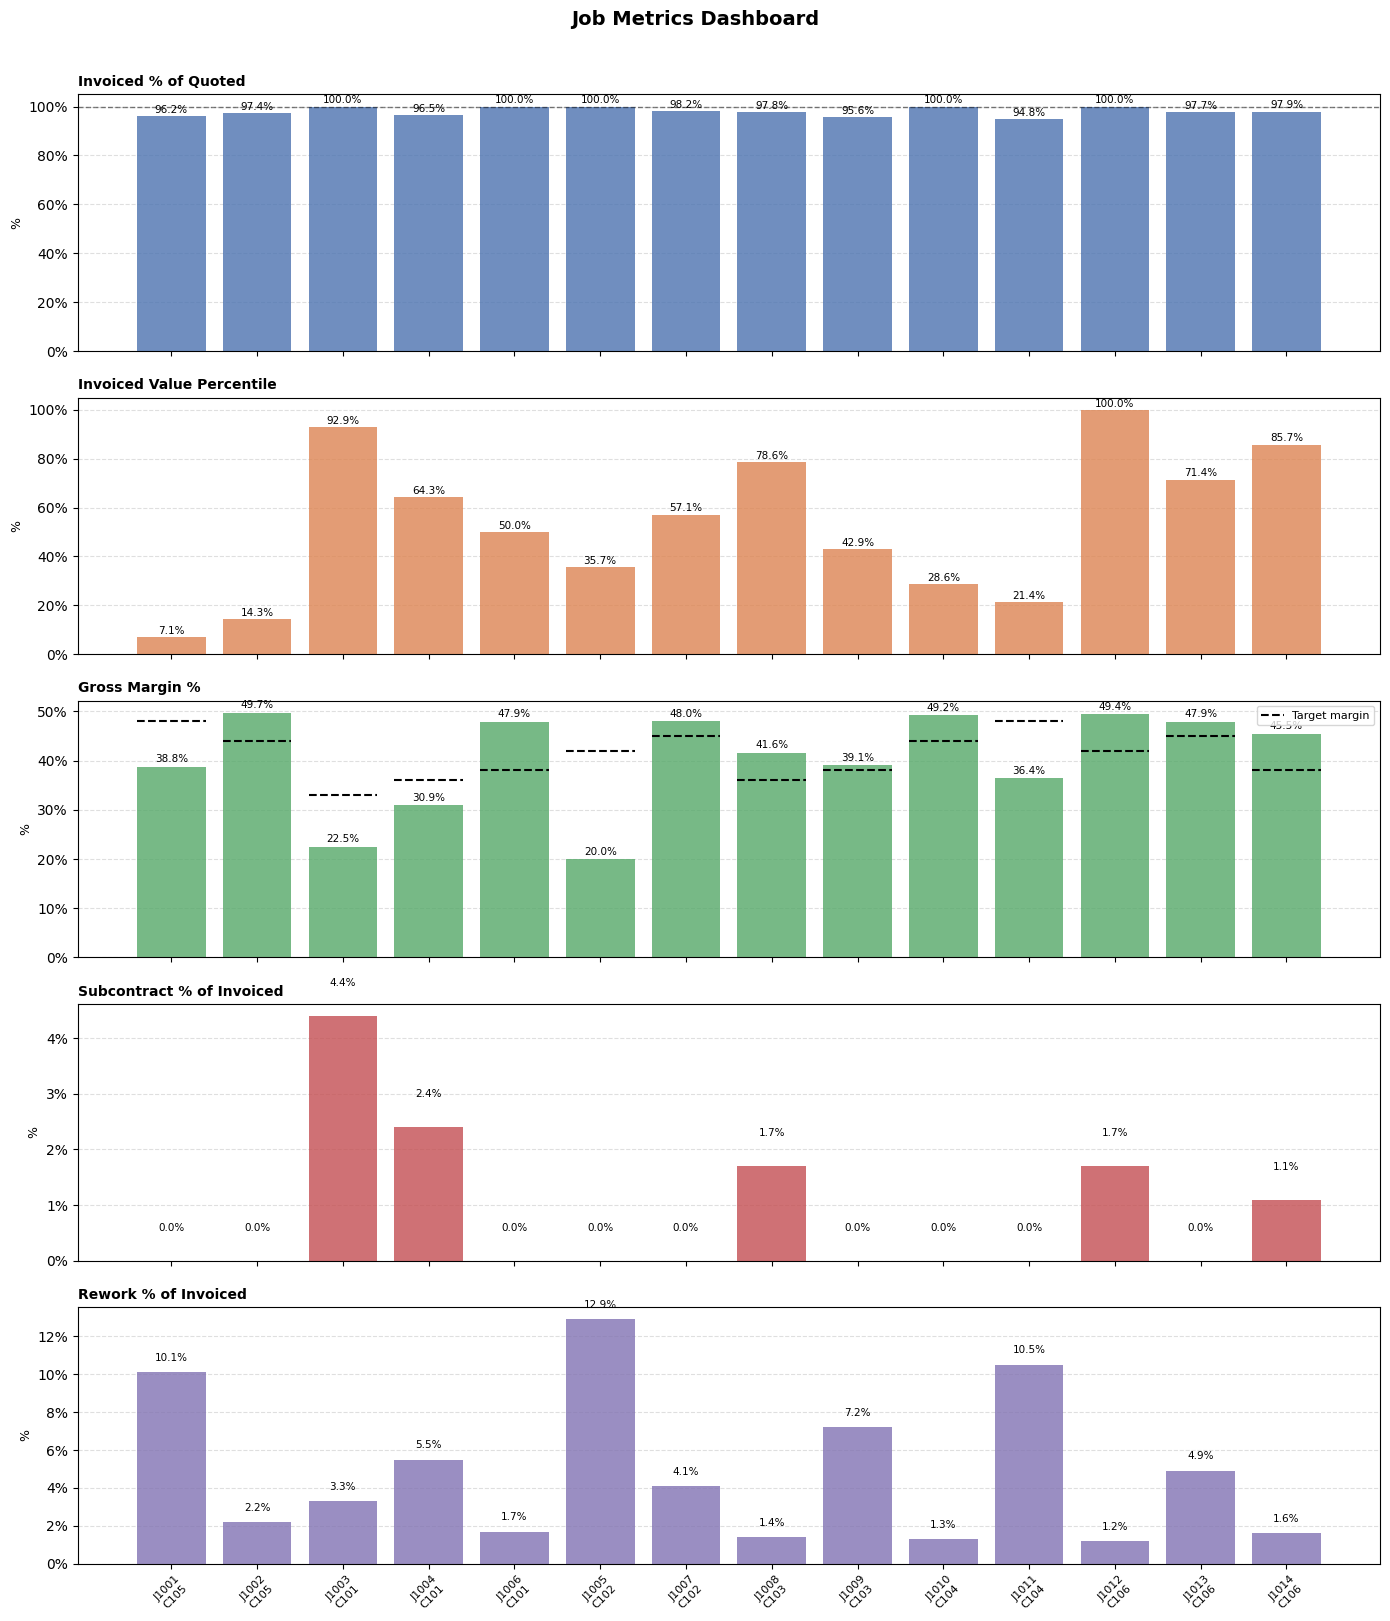

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

def plot_job_metrics(jobs_df, services_df):
    df = jobs_df.copy()

    # --- Derived metrics ---
    df['invoiced_pct_of_quoted'] = (df['invoiced_value_gbp'] / df['quoted_value_gbp'] * 100).round(1)
    df['invoiced_percentile'] = df['invoiced_value_gbp'].rank(pct=True).mul(100).round(1)
    df['subcontract_pct'] = (df['subcontract_gbp'] / df['invoiced_value_gbp'] * 100).round(1)
    df['rework_pct'] = (df['rework_gbp'] / df['invoiced_value_gbp'] * 100).round(1)

    svc_margin = services_df.set_index('service_id')['target_margin_pct']
    df['gross_margin_pct'] = df.apply(lambda r: round(
        (r['invoiced_value_gbp'] - r['direct_labour_gbp'] - r['travel_logistics_gbp']
         - r['subcontract_gbp'] - r['rework_gbp'] - r['other_direct_cost_gbp'])
        / r['invoiced_value_gbp'] * 100, 1), axis=1)
    df['target_margin_pct'] = df['service_id'].map(svc_margin)

    job_ids = df['job_id'].tolist()
    x = np.arange(len(job_ids))
    metrics = [
        ('invoiced_pct_of_quoted',  'Invoiced % of Quoted',        '#4C72B0', True),
        ('invoiced_percentile',     'Invoiced Value Percentile',   '#DD8452', False),
        ('gross_margin_pct',        'Gross Margin %',              '#55A868', True),
        ('subcontract_pct',         'Subcontract % of Invoiced',   '#C44E52', False),
        ('rework_pct',              'Rework % of Invoiced',        '#8172B3', False),
    ]

    fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 3.2 * len(metrics)), sharex=True)
    fig.suptitle('Job Metrics Dashboard', fontsize=14, fontweight='bold', y=1.01)

    for ax, (col, title, colour, show_target) in zip(axes, metrics):
        bars = ax.bar(x, df[col], color=colour, alpha=0.8, zorder=2)

        # Value labels on each bar
        for bar, val in zip(bars, df[col]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)

        # Target margin reference line on gross margin panel
        if show_target and col == 'gross_margin_pct':
            for i, (_, row) in enumerate(df.iterrows()):
                ax.plot([i - 0.4, i + 0.4], [row['target_margin_pct']] * 2,
                        color='black', linewidth=1.5, linestyle='--', zorder=3)
            ax.plot([], [], color='black', linewidth=1.5, linestyle='--', label='Target margin')
            ax.legend(fontsize=8, loc='upper right')

        # 100% reference line on invoiced % of quoted
        if col == 'invoiced_pct_of_quoted':
            ax.axhline(100, color='black', linewidth=1, linestyle='--', alpha=0.5)

        ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.set_ylabel('%', fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
        ax.set_ylim(bottom=0)
        ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
        ax.set_xticks(x)
        ax.tick_params(axis='x', labelrotation=45)

    # x-axis labels: job_id + customer_id
    axes[-1].set_xticklabels(
        [f"{r['job_id']}\n{r['customer_id']}" for _, r in df.iterrows()],
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

plot_job_metrics(jobs, services)

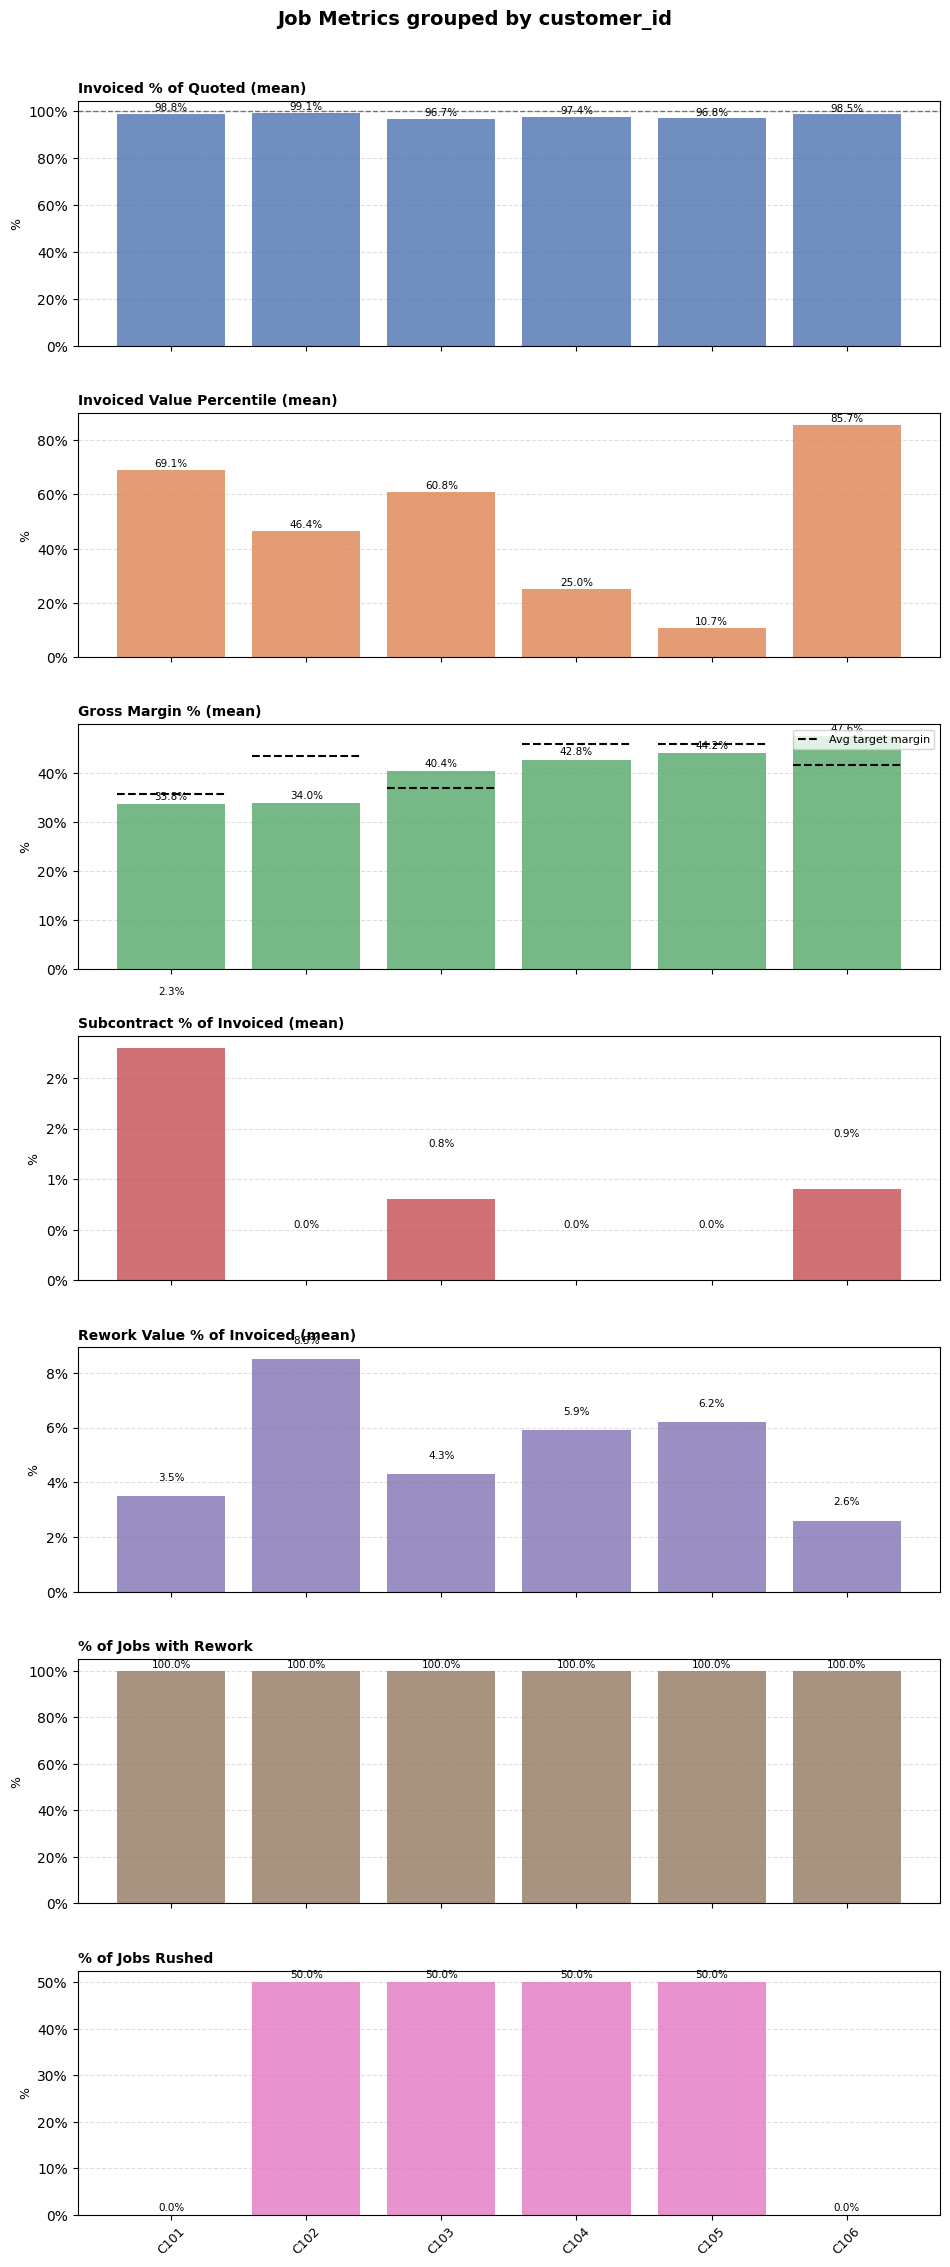

In [14]:
from typing import Literal

def plot_job_metrics_grouped(
    jobs_df,
    services_df,
    group_by: Literal['customer_id', 'subsidiary_id', 'service_id'],
):
    """
    Plot aggregated job metrics grouped by customer_id, subsidiary_id, or service_id.
    Each bar represents the mean of each metric across all jobs in that group.

    Args:
        jobs_df:     the jobs DataFrame
        services_df: the services DataFrame (for target margins)
        group_by:    one of 'customer_id', 'subsidiary_id', 'service_id'
    """
    if group_by not in ('customer_id', 'subsidiary_id', 'service_id'):
        raise ValueError("group_by must be one of: customer_id, subsidiary_id, service_id")

    df = jobs_df.copy()
    svc_margin = services_df.set_index('service_id')['target_margin_pct']

    df['invoiced_pct_of_quoted'] = (df['invoiced_value_gbp'] / df['quoted_value_gbp'] * 100).round(1)
    df['invoiced_percentile']    = df['invoiced_value_gbp'].rank(pct=True).mul(100).round(1)
    df['subcontract_pct']        = (df['subcontract_gbp'] / df['invoiced_value_gbp'] * 100).round(1)
    df['rework_value_pct']       = (df['rework_gbp'] / df['invoiced_value_gbp'] * 100).round(1)
    df['has_rework']             = (df['rework_gbp'] > 0).astype(int)
    df['gross_margin_pct']       = df.apply(lambda r: round(
        (r['invoiced_value_gbp'] - r['direct_labour_gbp'] - r['travel_logistics_gbp']
         - r['subcontract_gbp'] - r['rework_gbp'] - r['other_direct_cost_gbp'])
        / r['invoiced_value_gbp'] * 100, 1), axis=1)
    df['target_margin_pct']      = df['service_id'].map(svc_margin)
    df['is_rush']                = (df['rush_flag'] == 'Y').astype(int)

    metric_cols = ['invoiced_pct_of_quoted', 'invoiced_percentile',
                   'gross_margin_pct', 'subcontract_pct', 'rework_value_pct', 'target_margin_pct']
    agg = df.groupby(group_by)[metric_cols].mean().round(1)
    agg['rush_pct']         = df.groupby(group_by)['is_rush'].mean().mul(100).round(1)
    agg['rework_count_pct'] = df.groupby(group_by)['has_rework'].mean().mul(100).round(1)

    groups = agg.index.tolist()
    x = np.arange(len(groups))
    metrics = [
        ('invoiced_pct_of_quoted', 'Invoiced % of Quoted (mean)',         '#4C72B0'),
        ('invoiced_percentile',    'Invoiced Value Percentile (mean)',    '#DD8452'),
        ('gross_margin_pct',       'Gross Margin % (mean)',               '#55A868'),
        ('subcontract_pct',        'Subcontract % of Invoiced (mean)',    '#C44E52'),
        ('rework_value_pct',       'Rework Value % of Invoiced (mean)',   '#8172B3'),
        ('rework_count_pct',       '% of Jobs with Rework',              '#937860'),
        ('rush_pct',               '% of Jobs Rushed',                   '#E377C2'),
    ]

    fig, axes = plt.subplots(len(metrics), 1,
                             figsize=(max(8, len(groups) * 1.6), 3.2 * len(metrics)),
                             sharex=True)
    fig.suptitle(f'Job Metrics grouped by {group_by}', fontsize=14, fontweight='bold', y=1.01)

    for ax, (col, title, colour) in zip(axes, metrics):
        bars = ax.bar(x, agg[col], color=colour, alpha=0.8, zorder=2)

        for bar, val in zip(bars, agg[col]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)

        if col == 'gross_margin_pct':
            for i, grp in enumerate(groups):
                target = agg.loc[grp, 'target_margin_pct']
                ax.plot([i - 0.4, i + 0.4], [target, target],
                        color='black', linewidth=1.5, linestyle='--', zorder=3)
            ax.plot([], [], color='black', linewidth=1.5, linestyle='--', label='Avg target margin')
            ax.legend(fontsize=8, loc='upper right')

        if col == 'invoiced_pct_of_quoted':
            ax.axhline(100, color='black', linewidth=1, linestyle='--', alpha=0.5)

        ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.set_ylabel('%', fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
        ax.set_ylim(bottom=0)
        ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
        ax.set_xticks(x)
        ax.tick_params(axis='x', labelrotation=45)

    axes[-1].set_xticklabels(groups, fontsize=9)
    plt.tight_layout()
    plt.show()

# Usage examples:
# plot_job_metrics_grouped(jobs, services, 'customer_id')
# plot_job_metrics_grouped(jobs, services, 'subsidiary_id')
# plot_job_metrics_grouped(jobs, services, 'service_id')
plot_job_metrics_grouped(jobs, services, 'customer_id')

### Insights Agent

In [ ]:
from google.adk.agents.llm_agent import Agent
from google.adk import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

# -- Insight tools ------------------------------------------------------------

def get_margin_by_service() -> dict:
    """Returns average gross margin % per service, sorted ascending (worst first)."""
    df = jobs.copy()
    df['gross_margin_pct'] = df.apply(lambda r: round(
        (r['invoiced_value_gbp'] - r['direct_labour_gbp'] - r['travel_logistics_gbp']
         - r['subcontract_gbp'] - r['rework_gbp'] - r['other_direct_cost_gbp'])
        / r['invoiced_value_gbp'] * 100, 1), axis=1)
    result = df.groupby('service_id')['gross_margin_pct'].mean().round(1).sort_values()
    svc_names = services.set_index('service_id')['service_name']
    return {sid: {'service_name': svc_names[sid], 'avg_gross_margin_pct': val}
            for sid, val in result.items()}

def get_margin_by_subsidiary() -> dict:
    """Returns average gross margin % per subsidiary, sorted ascending (worst first)."""
    df = jobs.copy()
    df['gross_margin_pct'] = df.apply(lambda r: round(
        (r['invoiced_value_gbp'] - r['direct_labour_gbp'] - r['travel_logistics_gbp']
         - r['subcontract_gbp'] - r['rework_gbp'] - r['other_direct_cost_gbp'])
        / r['invoiced_value_gbp'] * 100, 1), axis=1)
    result = df.groupby('subsidiary_id')['gross_margin_pct'].mean().round(1).sort_values()
    sub_names = subsidiaries.set_index('subsidiary_id')['subsidiary_name']
    return {sid: {'subsidiary_name': sub_names[sid], 'avg_gross_margin_pct': val}
            for sid, val in result.items()}

def get_target_margin_leakage(group_by: str = 'service_id') -> dict:
    """
    Returns margin leakage (target minus actual) per group, sorted descending (worst first).
    group_by must be one of: service_id, subsidiary_id, customer_id.
    """
    if group_by not in ('service_id', 'subsidiary_id', 'customer_id'):
        return {'error': 'group_by must be service_id, subsidiary_id, or customer_id'}
    df = jobs.copy()
    df['gross_margin_pct'] = df.apply(lambda r: round(
        (r['invoiced_value_gbp'] - r['direct_labour_gbp'] - r['travel_logistics_gbp']
         - r['subcontract_gbp'] - r['rework_gbp'] - r['other_direct_cost_gbp'])
        / r['invoiced_value_gbp'] * 100, 1), axis=1)
    df['target_margin_pct'] = df['service_id'].map(services.set_index('service_id')['target_margin_pct'])
    df['leakage'] = (df['target_margin_pct'] - df['gross_margin_pct']).round(1)
    result = df.groupby(group_by)['leakage'].mean().round(1).sort_values(ascending=False)
    return {k: {'avg_leakage_pts': v} for k, v in result.items()}

def get_rush_rate(group_by: str = 'subsidiary_id') -> dict:
    """
    Returns percentage of rushed jobs per group, sorted descending.
    group_by must be one of: service_id, subsidiary_id, customer_id.
    """
    if group_by not in ('service_id', 'subsidiary_id', 'customer_id'):
        return {'error': 'group_by must be service_id, subsidiary_id, or customer_id'}
    df = jobs.copy()
    df['is_rush'] = (df['rush_flag'] == 'Y').astype(int)
    result = df.groupby(group_by)['is_rush'].mean().mul(100).round(1).sort_values(ascending=False)
    return {k: {'rush_pct': v} for k, v in result.items()}

def get_rework_stats(group_by: str = 'service_id') -> dict:
    """
    Returns rework value as % of invoiced and % of jobs with rework per group, sorted by rework_value_pct descending.
    group_by must be one of: service_id, subsidiary_id, customer_id.
    """
    if group_by not in ('service_id', 'subsidiary_id', 'customer_id'):
        return {'error': 'group_by must be service_id, subsidiary_id, or customer_id'}
    df = jobs.copy()
    df['rework_value_pct'] = (df['rework_gbp'] / df['invoiced_value_gbp'] * 100).round(1)
    df['has_rework'] = (df['rework_gbp'] > 0).astype(int)
    val = df.groupby(group_by)['rework_value_pct'].mean().round(1)
    cnt = df.groupby(group_by)['has_rework'].mean().mul(100).round(1)
    return {k: {'rework_value_pct': val[k], 'rework_count_pct': cnt[k]}
            for k in val.index.tolist()}

def plot_insights(group_by: str) -> dict:
    """
    Renders the job metrics chart grouped by the given dimension.
    group_by must be one of: customer_id, subsidiary_id, service_id.
    """
    if group_by not in ('customer_id', 'subsidiary_id', 'service_id'):
        return {'error': 'group_by must be customer_id, subsidiary_id, or service_id'}
    plot_job_metrics_grouped(jobs, services, group_by)
    return {'status': 'chart rendered', 'group_by': group_by}

# -- Agent --------------------------------------------------------------------

insights_agent = Agent(
    model=GeminiWithApiKey(model=model_name, api_key=api_key),
    name='bb_insights_agent',
    description='Answers commercial questions about margin, rework, rush rates and cross-sell across the buy-and-build portfolio.',
    instruction="""
You are a commercial analytics assistant for a buy-and-build group with three subsidiaries:
AlphaBiolabs (S1), JSS Medical Research (S2), and ARC Pharma (S3).

You have access to tools that compute margin, leakage, rework, rush rates, and charts.
Always call the relevant tool before answering. Never fabricate numbers.

When the user asks about profit, margin, or performance - use get_margin_by_service or get_margin_by_subsidiary.
When the user asks about target leakage - use get_target_margin_leakage.
When the user asks about rush jobs - use get_rush_rate.
When the user asks about rework - use get_rework_stats.
When the user asks for a chart or visual - use plot_insights.

Always name the specific service, subsidiary or customer in your answer with a brief explanation supported by facts in the available data. Be concise and commercial.
    """,
    tools=[
        get_margin_by_service,
        get_margin_by_subsidiary,
        get_target_margin_leakage,
        get_rush_rate,
        get_rework_stats,
        plot_insights,
    ],
)

# -- Runner & session ---------------------------------------------------------

INSIGHTS_APP     = 'insights_app'
INSIGHTS_USER    = 'insights_user_001'
INSIGHTS_SESSION = 'insights_session_001'

insights_session_service = InMemorySessionService()

insights_session = await insights_session_service.create_session(
    app_name=INSIGHTS_APP,
    user_id=INSIGHTS_USER,
    session_id=INSIGHTS_SESSION,
)

insights_runner = Runner(
    agent=insights_agent,
    app_name=INSIGHTS_APP,
    session_service=insights_session_service,
)

# -- Chatbot ------------------------------------------------------------------

async def ask_insights(message: str) -> str:
    content = types.Content(role='user', parts=[types.Part(text=message)])
    async for event in insights_runner.run_async(
        user_id=INSIGHTS_USER,
        session_id=INSIGHTS_SESSION,
        new_message=content,
    ):
        if event.is_final_response():
            text = '\n'.join(
                getattr(p, 'text', '') for p in event.content.parts if hasattr(p, 'text')
            )
            print(f'\nBot: {text}')
            return text



In [16]:
await ask_insights('Which service earns the least profit?')
# await ask_insights('Which subsidiary has the highest target margin leakage?')
# await ask_insights('Which customer has the most rushed jobs?')
# await ask_insights('Show me a rework breakdown by subsidiary')
# await ask_insights('Plot the metrics grouped by service')


Bot: The service earning the least profit is **Phase II/III Clinical Operations (SV4)**, which currently generates an average gross margin of **22.5%**.


'The service earning the least profit is **Phase II/III Clinical Operations (SV4)**, which currently generates an average gross margin of **22.5%**.'

In [17]:
await ask_insights('Show me a rework breakdown by subsidiary')


Bot: Here is the rework breakdown by subsidiary:

*   **AlphaBiolabs (S1):** Rework accounts for **6%** of invoiced value, with rework present in 100% of jobs.
*   **ARC Pharma (S3):** Rework accounts for **5.8%** of invoiced value, with rework present in 100% of jobs.
*   **JSS Medical Research (S2):** Rework accounts for **3.4%** of invoiced value, with rework present in 100% of jobs.

While all subsidiaries report rework across all jobs, AlphaBiolabs is currently experiencing the highest impact on margin value.


'Here is the rework breakdown by subsidiary:\n\n*   **AlphaBiolabs (S1):** Rework accounts for **6%** of invoiced value, with rework present in 100% of jobs.\n*   **ARC Pharma (S3):** Rework accounts for **5.8%** of invoiced value, with rework present in 100% of jobs.\n*   **JSS Medical Research (S2):** Rework accounts for **3.4%** of invoiced value, with rework present in 100% of jobs.\n\nWhile all subsidiaries report rework across all jobs, AlphaBiolabs is currently experiencing the highest impact on margin value.'

In [18]:
await ask_insights('What are the main causes of target leakage?')


Bot: The most significant margin leakage—where actual performance is falling furthest below target—is occurring in the following services:

*   **Phase II/III Clinical Operations (SV4):** 10.5 percentage points of leakage.
*   **Workplace Drug Testing (SV1):** 10.4 percentage points of leakage.
*   **QC Batch Release Testing (SV7):** 7.3 percentage points of leakage.

These three service lines are the primary drivers of our margin shortfall relative to targets. Conversely, services like Medical Writing & Data Management (SV6) and Occupational Health Screening (SV2) are currently outperforming their targets.


'The most significant margin leakage—where actual performance is falling furthest below target—is occurring in the following services:\n\n*   **Phase II/III Clinical Operations (SV4):** 10.5 percentage points of leakage.\n*   **Workplace Drug Testing (SV1):** 10.4 percentage points of leakage.\n*   **QC Batch Release Testing (SV7):** 7.3 percentage points of leakage.\n\nThese three service lines are the primary drivers of our margin shortfall relative to targets. Conversely, services like Medical Writing & Data Management (SV6) and Occupational Health Screening (SV2) are currently outperforming their targets.'

In [19]:
await ask_insights('What are the main causes of target leakage?')


Bot: The target margin leakage across our subsidiaries is as follows:

*   **AlphaBiolabs (S1):** 2.5 percentage points of leakage.
*   **ARC Pharma (S3):** 2.2 percentage points of leakage.
*   **JSS Medical Research (S2):** Currently outperforming its margin target by 1.4 percentage points.

While the previous service-level analysis identified **Phase II/III Clinical Operations** and **Workplace Drug Testing** as the primary contributors to leakage, at the subsidiary level, AlphaBiolabs and ARC Pharma are the groups failing to meet their overall margin targets.


'The target margin leakage across our subsidiaries is as follows:\n\n*   **AlphaBiolabs (S1):** 2.5 percentage points of leakage.\n*   **ARC Pharma (S3):** 2.2 percentage points of leakage.\n*   **JSS Medical Research (S2):** Currently outperforming its margin target by 1.4 percentage points.\n\nWhile the previous service-level analysis identified **Phase II/III Clinical Operations** and **Workplace Drug Testing** as the primary contributors to leakage, at the subsidiary level, AlphaBiolabs and ARC Pharma are the groups failing to meet their overall margin targets.'

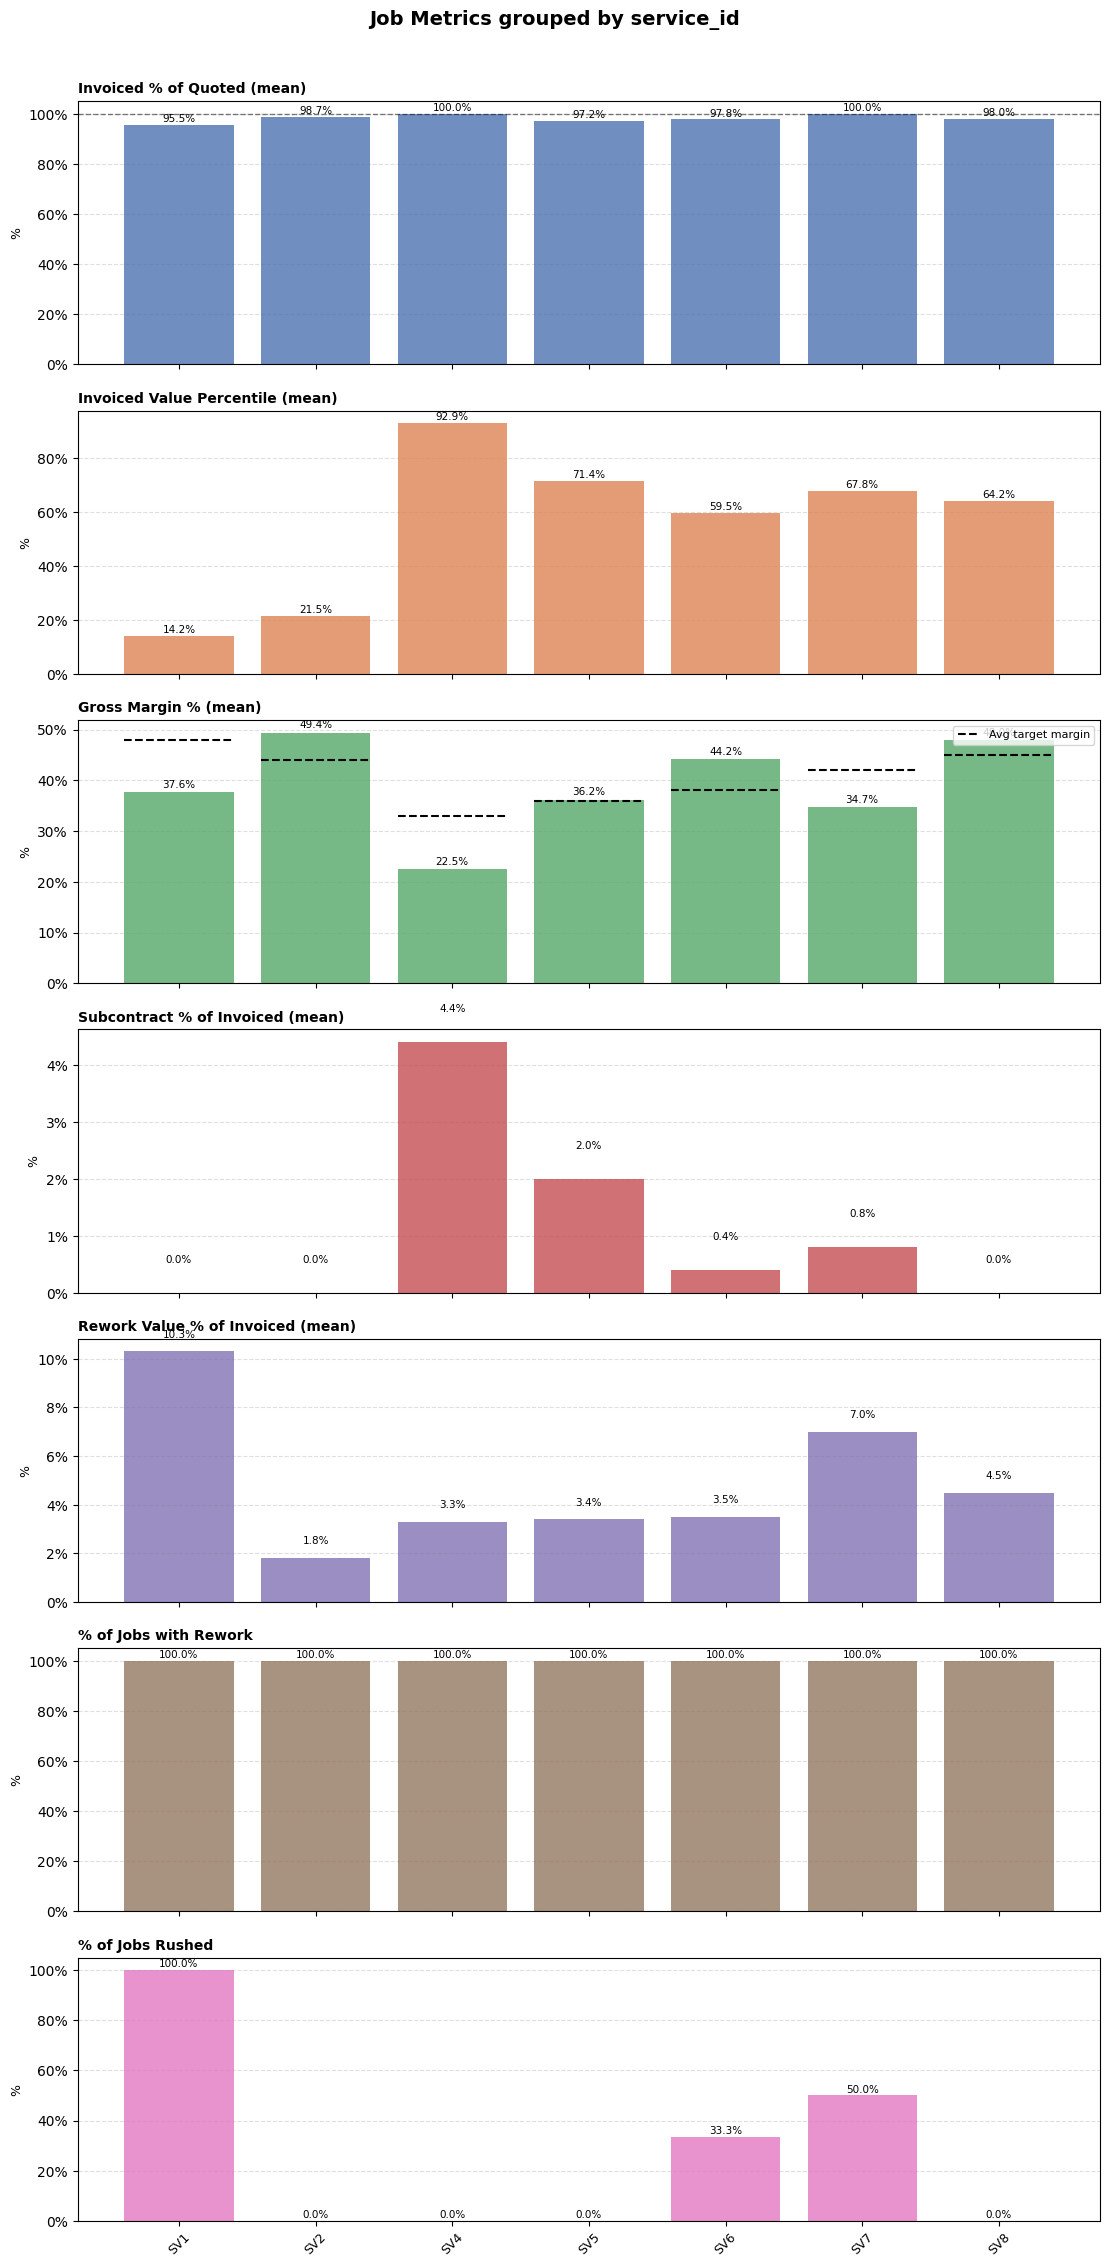


Bot: The job metrics chart, grouped by service, has been rendered. This visualization will allow you to compare performance across our service portfolio at a glance.


'The job metrics chart, grouped by service, has been rendered. This visualization will allow you to compare performance across our service portfolio at a glance.'

In [20]:
await ask_insights('Plot the metrics grouped by service')

### Deterministic business logic

scoring.py

In [21]:
from __future__ import annotations

def gross_margin_pct(invoiced, labour, travel, subcontract, rework, other):
    if invoiced <= 0:
        return 0.0
    margin = (
        invoiced - labour - travel - subcontract - rework - other
    ) / invoiced
    return round(margin * 100, 2)

def cross_sell_score(
    adjacency_conf: float,
    sector_fit: float,
    region_fit: float,
    spend_band_fit: float,
    capacity_score: float
) -> float:
    score = (
        0.35 * adjacency_conf
        + 0.20 * sector_fit
        + 0.15 * region_fit
        + 0.15 * spend_band_fit
        + 0.15 * capacity_score
    )
    return round(score, 4)

def priority_band(score: float) -> str:
    if score >= 0.80:
        return "HIGH"
    if score >= 0.65:
        return "MEDIUM"
    return "LOW"

tools.py

In [22]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
# from scoring import gross_margin_pct, cross_sell_score, priority_band

def resolve_customer(customer_name: str) -> dict:
    """
    Resolve a customer name to the closest known group customer.
    """
    match = customers[customers["customer_name"].str.lower() == customer_name.lower()]
    if match.empty:
        return {"status": "not_found", "customer_name": customer_name}
    row = match.iloc[0].to_dict()
    return {"status": "success", "customer": row}

def get_customer_360(customer_id: str) -> dict:
    """
    Return customer profile plus current service history.
    """
    cust = customers[customers["customer_id"] == customer_id]
    hist = history[history["customer_id"] == customer_id]
    if cust.empty:
        return {"status": "not_found", "customer_id": customer_id}
    return {
        "status": "success",
        "customer": cust.iloc[0].to_dict(),
        "service_history": hist.to_dict(orient="records")
    }

def find_cross_sell_opportunities(customer_id: str) -> dict:
    """
    Recommend likely next services across the portfolio.
    """
    cust = customers[customers["customer_id"] == customer_id]
    hist = history[history["customer_id"] == customer_id]
    if cust.empty:
        return {"status": "not_found", "customer_id": customer_id}
    current_services = set(hist["service_id"].tolist())
    sector = cust.iloc[0]["sector"]
    region = cust.iloc[0]["region"]
    spend = float(cust.iloc[0]["current_group_spend_gbp"])
    opportunities = []
    for _, hrow in hist.iterrows():
        anchor = hrow["service_id"]
        rules = adjacency[adjacency["anchor_service_id"] == anchor]
        for _, rule in rules.iterrows():
            recommended = rule["recommended_service_id"]
            if recommended in current_services:
                continue
            svc = services[services["service_id"] == recommended].iloc[0]
            provider = subsidiaries[subsidiaries["subsidiary_id"] == svc["provider_subsidiary_id"]].iloc[0]
            sector_fit = 1.0 if sector in ["Pharma", "Biotech"] and recommended in ["SV5", "SV6", "SV7", "SV8"] else 0.7
            region_fit = 0.9 if region in ["UK", "EU", "Global"] else 0.7
            spend_band_fit = 1.0 if spend >= 200000 else 0.7
            capacity_score = max(0.1, 1 - (float(provider["current_capacity_pct"]) / 100))
            score = cross_sell_score(
                adjacency_conf=float(rule["base_confidence"]),
                sector_fit=sector_fit,
                region_fit=region_fit,
                spend_band_fit=spend_band_fit,
                capacity_score=capacity_score
            )
            opportunities.append({
                "customer_id": customer_id,
                "customer_name": cust.iloc[0]["customer_name"],
                "recommended_service_id": recommended,
                "recommended_service_name": svc["service_name"],
                "recommended_subsidiary_id": svc["provider_subsidiary_id"],
                "recommended_subsidiary_name": provider["subsidiary_name"],
                "estimated_annual_value_gbp": int(svc["avg_deal_size_gbp"]),
                "score": score,
                "priority": priority_band(score),
                "reason": rule["reason"]
            })
    opportunities = sorted(opportunities, key=lambda x: x["score"], reverse=True)
    return {"status": "success", "opportunities": opportunities[:5]}

def find_margin_leaks(customer_id: str | None = None) -> dict:
    """
    Flag jobs where actual margin is below target margin.
    """
    jobs_df = jobs.copy()
    if customer_id:
        jobs_df = jobs_df[jobs_df["customer_id"] == customer_id]
    results = []
    for _, row in jobs_df.iterrows():
        target_margin = float(
            services[services["service_id"] == row["service_id"]].iloc[0]["target_margin_pct"]
        )
        actual_margin = gross_margin_pct(
            invoiced=float(row["invoiced_value_gbp"]),
            labour=float(row["direct_labour_gbp"]),
            travel=float(row["travel_logistics_gbp"]),
            subcontract=float(row["subcontract_gbp"]),
            rework=float(row["rework_gbp"]),
            other=float(row["other_direct_cost_gbp"])
        )
        leak = round(target_margin - actual_margin, 2)
        if leak > 5:
            reasons = []
            if str(row["rush_flag"]) == "Y":
                reasons.append("rush_work_not_fully_recovered")
            if float(row["rework_gbp"]) > 1000:
                reasons.append("rework_cost_high")
            if float(row["travel_logistics_gbp"]) > 1000:
                reasons.append("travel_or_logistics_overrun")
            if float(row["quoted_value_gbp"]) > float(row["invoiced_value_gbp"]):
                reasons.append("quote_to_invoice_erosion")
            results.append({
                "job_id": row["job_id"],
                "customer_id": row["customer_id"],
                "service_id": row["service_id"],
                "actual_margin_pct": actual_margin,
                "target_margin_pct": target_margin,
                "margin_leak_pct": leak,
                "reasons": reasons
            })
    return {"status": "success", "margin_leaks": results}

def prioritise_actions(customer_id: str) -> dict:
    """
    Combine cross-sell and margin findings into a next-best-action list.
    """
    cross_sell = find_cross_sell_opportunities(customer_id)
    leaks = find_margin_leaks(customer_id)
    actions = []
    for leak in leaks.get("margin_leaks", []):
        severity = "HIGH" if leak["margin_leak_pct"] >= 10 else "MEDIUM"
        actions.append({
            "type": "margin_leak",
            "priority": severity,
            "message": f"Review pricing and delivery controls for job {leak['job_id']}; leak={leak['margin_leak_pct']} pts.",
            "approval_required": True
        })
    for opp in cross_sell.get("opportunities", []):
        approval_required = opp["priority"] != "HIGH"
        actions.append({
            "type": "cross_sell",
            "priority": opp["priority"],
            "message": f"Offer {opp['recommended_service_name']} via {opp['recommended_subsidiary_name']} to {opp['customer_name']}.",
            "approval_required": approval_required
        })
    priority_order = {"HIGH": 0, "MEDIUM": 1, "LOW": 2}
    actions = sorted(actions, key=lambda x: priority_order[x["priority"]])
    return {"status": "success", "actions": actions}

agent.py

In [23]:
from google.adk.agents.llm_agent import Agent
# from tools import (
#     resolve_customer,
#     get_customer_360,
#     find_cross_sell_opportunities,
#     find_margin_leaks,
#     prioritise_actions,
# )

root_agent = Agent(
    model=GeminiWithApiKey(model=model_name, api_key=api_key),
    name="buy_build_revenue_margin_agent",
    description="Finds cross-sell opportunities and margin leaks across a buy-and-build portfolio.",
    instruction="""
You are an enterprise revenue and margin intelligence agent for a buy-and-build group.

Your job:
1. Resolve the customer name.
2. Retrieve the customer 360.
3. Identify cross-sell opportunities across subsidiaries.
4. Identify margin leaks for the customer's recent jobs.
5. Prioritise recommended actions.
6. Return a concise executive summary plus a structured JSON block.

Rules:
- Never fabricate customer data.
- Use tools before answering.
- If an action is pricing-sensitive or medium-confidence, mark it as human approval required.
- Keep recommendations concrete and commercial.
    """,
    tools=[
        resolve_customer,
        get_customer_360,
        find_cross_sell_opportunities,
        find_margin_leaks,
        prioritise_actions,
    ],
)

In [24]:
from google.adk import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

APP_NAME = "synergy_app"
USER_ID = "demo_user_001"
SESSION_ID = "sessiondemo_001"

session_service = InMemorySessionService()

# Create a session once for the notebook
session = await session_service.create_session(
    app_name=APP_NAME,
    user_id=USER_ID,
    session_id=SESSION_ID,
)

runner = Runner(
    agent=root_agent,
    app_name=APP_NAME,
    session_service=session_service
)

In [25]:
async def ask_bot(message: str, session_id: str = SESSION_ID, user_id: str = USER_ID):
    content = types.Content(
        role="user",
        parts=[types.Part(text=message)]
    )

    async for event in runner.run_async(
        user_id=user_id,
        session_id=session_id,
        new_message=content
    ):
        if hasattr(event, "tool_name") and event.tool_name:
            print(f"\nTool Called: {event.tool_name}")

        if hasattr(event, "tool_args") and event.tool_args:
            print(f"   Args: {event.tool_args}")

        if hasattr(event, "raw_event") and event.raw_event:
            raw = event.raw_event
            if isinstance(raw, dict) and "tool" in str(raw).lower():
                print(f"\nRaw Event (possible tool call): {raw}")

        if event.is_final_response():
            text = "\n".join(
                getattr(part, "text", "") for part in event.content.parts if hasattr(part, "text")
            )
            print(f"\nBot: {text}")
            return text

In [27]:
await ask_bot("Find cross-sell opportunities for MedNova Pharma")


Bot: ### Executive Summary: MedNova Pharma (C101)

MedNova Pharma is a high-value client with £420k annual spend. Analysis reveals a clear, high-priority cross-sell opportunity and significant margin pressure on recent service delivery.

*   **Cross-Sell Opportunity:** We recommend introducing **ARC Pharma (S3)** to provide **QC Batch Release Testing**. Based on their current clinical stage, this is a natural expansion with an estimated annual value of **£140k**.
*   **Margin Health:** We have identified two jobs (J1003 and J1004) suffering from margin leaks caused by rework and logistics overruns. Job J1003 is of particular concern with a 10.5% deficit against the target margin.
*   **Next Steps:** Immediate action is required to address the margin leaks on the existing accounts (requiring human approval for pricing/process review) before proceeding with the cross-sell expansion.

```json
{
  "customer_name": "MedNova Pharma",
  "customer_id": "C101",
  "summary": {
    "annual_spend

'### Executive Summary: MedNova Pharma (C101)\n\nMedNova Pharma is a high-value client with £420k annual spend. Analysis reveals a clear, high-priority cross-sell opportunity and significant margin pressure on recent service delivery.\n\n*   **Cross-Sell Opportunity:** We recommend introducing **ARC Pharma (S3)** to provide **QC Batch Release Testing**. Based on their current clinical stage, this is a natural expansion with an estimated annual value of **£140k**.\n*   **Margin Health:** We have identified two jobs (J1003 and J1004) suffering from margin leaks caused by rework and logistics overruns. Job J1003 is of particular concern with a 10.5% deficit against the target margin.\n*   **Next Steps:** Immediate action is required to address the margin leaks on the existing accounts (requiring human approval for pricing/process review) before proceeding with the cross-sell expansion.\n\n```json\n{\n  "customer_name": "MedNova Pharma",\n  "customer_id": "C101",\n  "summary": {\n    "annu

In [ ]:
# -- Example queries ----------------------------------------------------------
# await ask_insights('Which service earns the least profit?')
# await ask_insights('Which subsidiary has the highest target margin leakage?')
# await ask_insights('Which customer has the most rushed jobs?')
# await ask_insights('Show me a rework breakdown by subsidiary')
# await ask_insights('Plot the metrics grouped by service')
# await ask_insights('Which service earns the least profit?')